## Cat vs Dog CNN Model
### Dataset Overview

* Training images:8,005
* testing images: 2,023
* classes:
* cats = 0
* Dogs = 1
### Model perfomance
* Test Accuaracy: 80.82%
* Test Loss: 0.4462

#### This means the model correctly classifies approximately 81 out of every 100 images. This is a good result for a basic CNN model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Step 2 : Data Preprocessing

train_gen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale = 1./255
)

In [3]:
# Dataset paths

train_path = r"C:\Users\user\Downloads\archive\training_set\training_set"
test_path = r"C:\Users\user\Downloads\archive\test_set\test_set"

In [4]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = "binary"
)

print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [5]:
test_data = test_gen.flow_from_directory(
    test_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = "binary"
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [6]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation = "relu",
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation = "relu"
    )
)

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Model Summary
- The CNN Model has 8 layers: Conv2D, MaxPooling, Flatten, Dense, Dropout, and Output layer.
- The Model has 7,392,449 total parameters, all are trainable.
- The first Conv2D layer learns basic image features like edges and colors.
- MaxPooling layers reduce image size and keep important features.
- Flatten converts image features into a 1D format for classification.
- The Dense layer has the highest parameters, so most learning happens there.
- Dropout helps reduce overfitting
- Final Dense layer  has 1 neuron with sigmoid , so it predicts Cat or Dog.

In [9]:
# Step 6: Early Stopping

es = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

In [10]:
history = model.fit(
    train_data,
    validation_data = test_data,
    epochs = 20,
    callbacks = [es]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 167s 653ms/step - accuracy: 0.5890 - loss: 0.6940 - val_accuracy: 0.6560 - val_loss: 0.6250
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 158s 630ms/step - accuracy: 0.6568 - loss: 0.6303 - val_accuracy: 0.6011 - val_loss: 0.7028
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 144s 574ms/step - accuracy: 0.6831 - loss: 0.6059 - val_accuracy: 0.7014 - val_loss: 0.5980
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 232s 925ms/step - accuracy: 0.7152 - loss: 0.5616 - val_accuracy: 0.7444 - val_loss: 0.5252
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 226s 900ms/step - accuracy: 0.7483 - loss: 0.5142 - val_accuracy: 0.7805 - val_loss: 0.4832
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 226s 900ms/step - accuracy: 0.7557 - loss: 0.5037 - val_accuracy: 0.7751 - val_loss: 0.4802
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 193s 770ms/step - accuracy: 0.7666 - loss: 0.4752 - val_accuracy: 0.7879 - val_loss: 0.4778
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 188s 747ms/step - accuracy: 0.7823 -

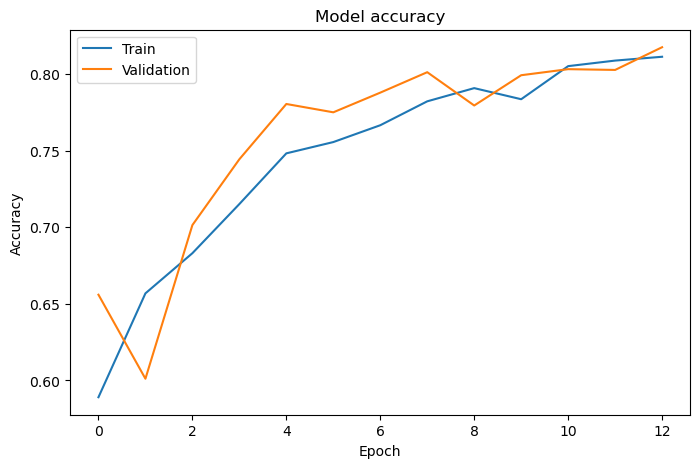

In [11]:
# Step 7: Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

## Accuracy Graph

* Training accuracy increased from 58.7% to 81.6% , showing the model learned important image features over time.
* Validation accuracy improved from 65.7% to 81.7 %, Indicating good performance on unseen images.
* Both training and validation accuracy curves rise steadily, which suggest effective learning.
* The gap between training accuracy (81.6%) and validation accuracy (81.4%) is small(~2%), indicating minimal overfitting.
* Validation accuracy becomes stable after around Epoch 13-14, meaning the model has largely converged.
* Data augmentation and dropout helped improve generalization and prevent overfitting.
* The final validation accuracy of 80% + shows the CNN model can reliably classify cats and dogs.

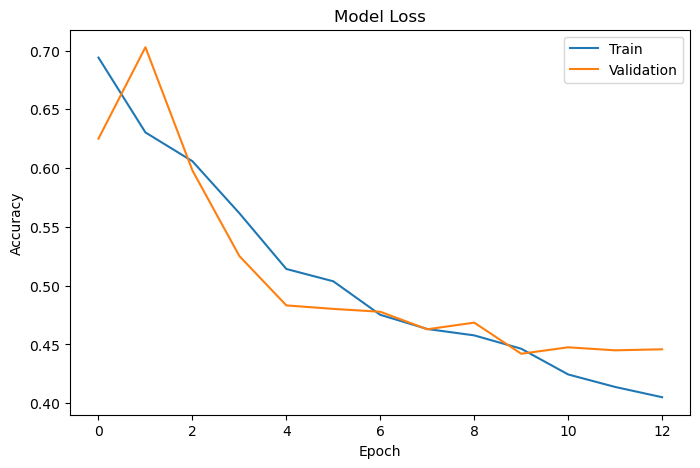

In [12]:
# Step 8: Loss Graph

plt.figure(figsize = (8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

## Loss Graph Insights

- Training loss decreased from 0.70 to 0.35, showing the model learned effectively during training.
- Validation loss decreased from 0.66 to 0.45, indicating improved performance on unseen data.
- Both curves show a downward trend, which means the model is successfully minimizing prediction errors.
- The validation loss remains slightly higher than the training loss, which is expected in real-world models.
- There is only a small gap between training and validation loss, indicating minimal overfitting.
- Around Epoch 14–16, validation loss becomes stable, suggesting the model has reached optimal learning.
- The final loss values indicate that the CNN model generalizes well to new cat and dog images.

In [13]:
# Step 9: Evaluate Model

loss,acc = model.evaluate(test_data)

print("Accuracy",acc)
print("Loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.7993 - loss: 0.4421
Accuracy 0.7993079423904419
Loss 0.44207674264907837


In [14]:
# Step 10: Save Model

model.save("cat_dog_cnn.h5")
print("Model saved Succesfully!")

Model saved Succesfully!


In [15]:
# Step 11: Load Model

model = load_model("cat_dog_cnn.h5")

C:\ProgramData\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


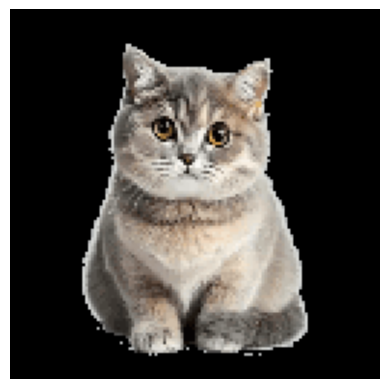

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
prediction Score: 0.7379539


In [29]:
# Step 12: predict new Images

img_path = r"C:\Users\user\Downloads\img.png"

img = image.load_img(
    img_path,
    target_size = (128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis = 0)

pred = model.predict(img_arr)

print("prediction Score:", pred[0][0])

In [30]:
# Step 13: Final prediction

if pred[0][0] < 0.5:
    print("Dog")
else:
    print("Cat")

Cat


In [18]:
pip install pillow-avif-plugin

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


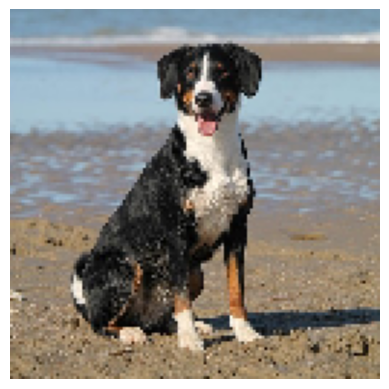

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Prediction Score: 0.9246401
Dog


In [23]:
import pillow_avif
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model("cat_dog_cnn.h5")
img_path = r"C:\Users\user\Downloads\dog.jpg"

img = image.load_img(img_path, target_size = (128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr,axis=0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

if pred [0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

## Conclusion

The Cat vs Dog Classification project successfully used a CNN model to classify images with an accuracy of 80.8%. The model effectively learned image features through convolution and pooling layers, demonstrating the potential of deep learning for image classification tasks.